# How to calculate the spatial gradient of a scalar field in cylindrical coordiantes

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

### Cylindrical coordinates:

FELiCS is able to handle cartesian and cylindrical coordinates. The cylindrical coordinates in FELiCS are defined with (x, r, theta) where x is analogous to the x in cartesian coordinates, r is the radial component (distance from x-axis) and theta is the azimuthal/angular coordinate which is the angle around the x-axis.
with this coordinate choice our square mesh is basically "rolled" into a cylinder.

**TODO** put equation of gradient with derivative w.r.t. spectral dimension (if any doubt, see https://en.wikipedia.org/wiki/Del_in_cylindrical_and_spherical_coordinates)

In [1]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.IO.Reader            import Reader
from FELiCS.SpaceDisc.FEMSpaces  import create_function_space
from FELiCS.Fields.Field         import Field

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cylindrical"
m = 3

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName, meshFileName)

space = create_function_space(mesh, degree=2, dim=1)

phi = Field(space, mesh, name="function_sine_cos") 
phi.import_data(Reader(), "input.h5")


(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


fatal: not a git repository: '/home/demange/anaconda3/envs/felics/lib/python3.13/site-packages/../.git'
Info     | FELiCSMesh.py          | __init__                   (line 124 ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 132 ) : Mesh contains 513 nodes and 1024 elements
Info     | Reader.py              | _interpolate_to_calc_mesh  (line 706 ) : Linear interpolation took 0.1 seconds. (Mesh size: (1969, 2))


(<FELiCS.Fields.Field.Field at 0x7cfc3aba4ad0>, [])

**Step 2: Calculate the gradient**

We now want to calculate the gradient of our scalar quantity using the `getGradient()` method of our Field class. This method returns a Field 

In [2]:
gradPhi = phi.get_gradient_field()


**Step 3: Postprocessing**

Visualization of the gradients with 

<Axes: xlabel='x', ylabel='y'>

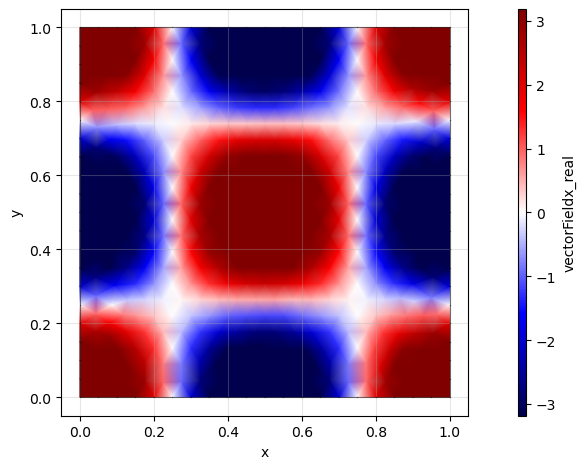

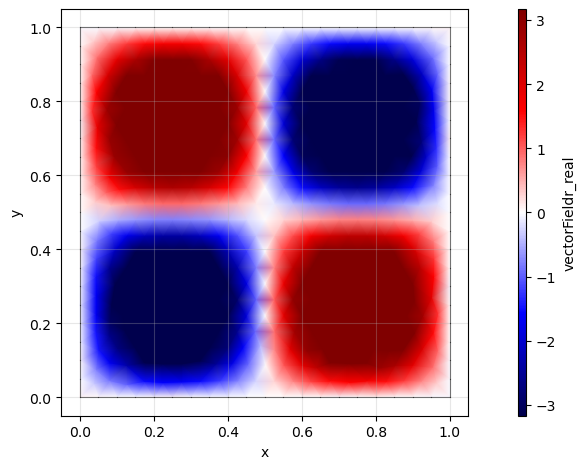

In [3]:
gradPhiList = gradPhi.get_list_of_sub_fields()
phi_x = gradPhiList[0]
phi_r = gradPhiList[1]
phi_x.plot()
phi_r.plot()

### Cylindrical coordinates with spectral dimension
Here, to the two spatial dimensions (x and r) a third spectral dimension in theta-direction is added.
With the spectral dimension the scalar field becomes

$$\phi \cdot e^{im\theta}$$

where m is the wave number. With the wave number we represent a periodicity of the flow in theta-direction, while still only calculating a 2D flowfield.

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

In [4]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.SpaceDisc.FEMSpaces  import create_function_space
from FELiCS.Fields.Field         import Field
from FELiCS.IO.Reader            import Reader

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cylindrical"
m = 2

# create a FELiCS mesh from the gmsh file
# by setting m to an integer number that is not zero, the spectral direction is added to the coordinate system
mesh = FELiCSMesh(coordinateSystemName, meshFileName, m=m) 

# create a scalar space
scalarSpace = create_function_space(mesh, degree=2, dim=1)

# create a Field object and import the data from the h5 file
# by setting m to an integer number that is not zero, the spectral direction is added to the field
phi = Field(scalarSpace, mesh=mesh, name = "function_sine_cos", m = m) 
phi.import_data(Reader(),"input.h5")


Info     | FELiCSMesh.py          | __init__                   (line 124 ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 132 ) : Mesh contains 513 nodes and 1024 elements
Info     | Reader.py              | _interpolate_to_calc_mesh  (line 706 ) : Linear interpolation took 0.1 seconds. (Mesh size: (1969, 2))


(<FELiCS.Fields.Field.Field at 0x7cfc3a49efd0>, [])

**Step 2: Calculate the gradient**

With the spectral dimension, the gradient is now 3-dimensional:

$$\nabla \phi = \left(...\right)$$

and it is defined as:

$$\nabla \phi = \begin{pmatrix}
... \\
... \\
...
\end{pmatrix}\ .$$



In [5]:
gradPhi = phi.get_gradient_field() # this is a vector field

# get scalar fields from gradient:
gradList = gradPhi.get_list_of_sub_fields()
phi_x    = gradList[0]
phi_r    = gradList[1]
phi_t    = gradList[2]

**Step 3: Postprocessing**

Exporting as h5 file and visualization of the gradients by using the FELiCS plotting function:


<Axes: xlabel='x', ylabel='y'>

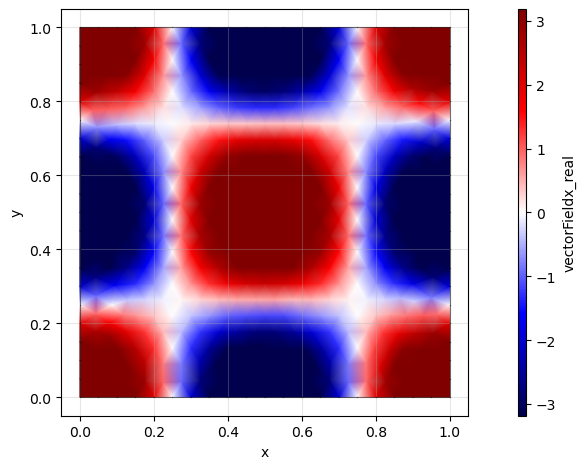

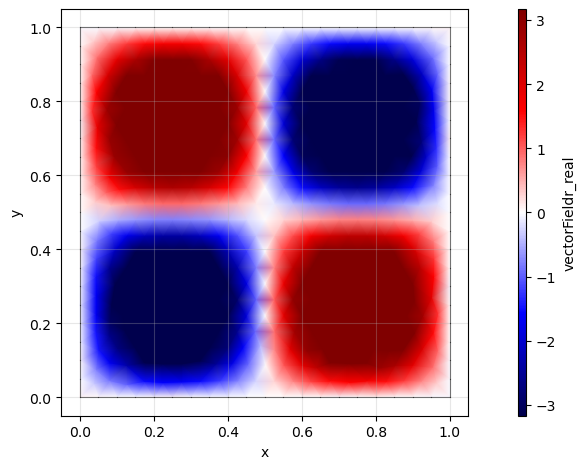

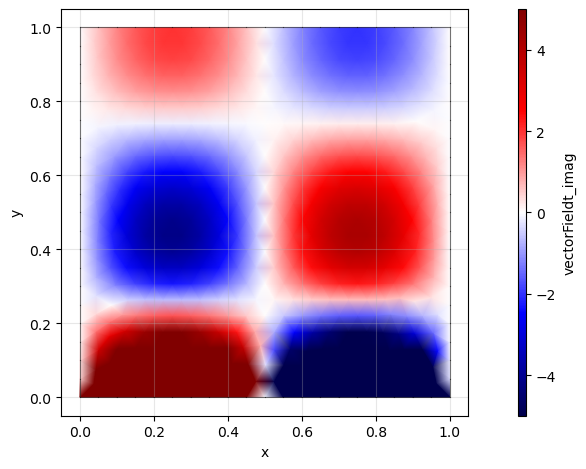

In [6]:
from FELiCS.IO.Writer import Writer
gradPhi.export_to_h5(Writer())

phi_x.plot()
phi_r.plot()
phi_t.plot(plotType="imag", clim=(-5,5))